/Users/kotafukuda/Documents/Project_univ/repair/.venv/lib/python3.12/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3588.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


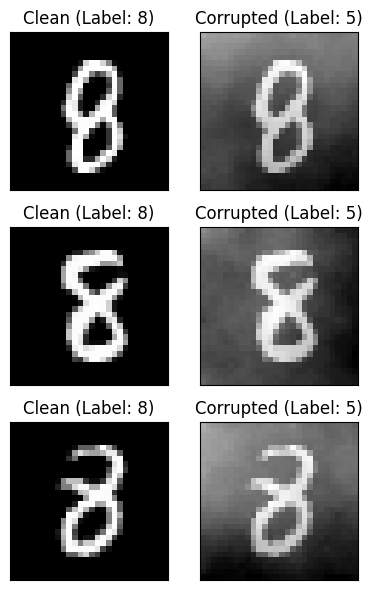

In [2]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname("__file__"), ".."))

from net.util import get_net
from input_space.generate_input import repair_points, repair_regions
from repair.args import RepairArgs
from input_space.dataset import Dataset
from repair.args import RepairTask
from input_space.display_image_c import visualize_clean_vs_corrupt


net_dataset_map = {
    0: ( "mnist 9x100", Dataset.MNIST ),
    1: ( "mnist_256x4", Dataset.MNIST ),
    2: ( "mnist_256x6", Dataset.MNIST ),
    3: ( "mnist_conv", Dataset.MNIST ),
    4: ( "cifar10_S", Dataset.CIFAR10 ),
    5: ( "cifar10_M", Dataset.CIFAR10 ),
    6: ( "cifar10_L", Dataset.CIFAR10 ),
}
net_dataset_index = 0
model_name, dataset = net_dataset_map[net_dataset_index]
repair_task = RepairTask.CorruptionAndPerturbation

args = RepairArgs(repair_task=repair_task, model_name=model_name, dataset=dataset)

net, _, _ = get_net(args, debug=True)

repaired_indices, repaired_points, base_points = repair_points(args, net)

visualize_clean_vs_corrupt(args, net, base_points, repaired_points, n=3)